# Loan Approval Model for FinTech Innovations
### Predicting approval decisions with a cost-aware, interpretable classifier (CRISP-DM)

## Overview

**Bottom line:** a tuned, regularised **logistic regression** predicts the historical approval decision with a **test ROC-AUC of 0.995** and **PR-AUC of 0.984**. When its decision threshold is set from the business costs (approve only when P(approved) is high, about 0.85), it costs **about $602 per applicant** on the held-out test set, against **$1,912** for denying everyone and **$38,050** for approving everyone. On the 4,000 test applications, that is roughly **$5.2M (about 68%) less** than the best naive policy. The model makes only 19 false approvals in 4,000 applications; its main cost is conservative false denials (182). Simpler beat more complex here: logistic regression outperformed Random Forest and gradient boosting in cross-validation and is the easiest model to explain to a regulator. Debt-to-income, interest rate, income and net worth drive the decisions.

**The story:** the current process is manual and inconsistent. We standardise it with a model whose errors are weighted by their real dollar cost, and we document its limits: the labels are past *decisions* (not repayment outcomes), the data is synthetic and rule-generated (which is why scores are so high), and some inputs (age, marital status) need compliance review before production use.

## Business Understanding

### 1. Business context

**Current process and limitations.** Loan officers manually review applications. That leads to *inconsistent* decisions (two officers can treat the same applicant differently), *slow* response times, and no audit trail of why a decision was made. It also risks missing creditworthy applicants who do not fit traditional criteria.

**Stakeholders and needs.**

| Stakeholder | Need |
|---|---|
| Loan officers | A fast, consistent recommendation they can understand and override |
| Risk / credit management | Fewer defaults; an explicit, measurable cost trade-off |
| Compliance and regulators | Explainable, auditable, non-discriminatory decisions |
| Partner banks (FinTech's clients) | Higher throughput without higher losses |
| Applicants | Fast, fair decisions and creditworthy people not being turned away |

**Implications of model errors (asymmetric).**
- **False approval** (model approves an applicant who should have been denied) is treated as a bad loan: about **$50,000** loss.
- **False denial** (model denies a creditworthy applicant) loses about **$8,000** of profit.
- A false approval is therefore **6.25x** as costly. For a calibrated model, approving is worth it only when P(approved) x $8,000 > (1 - P(approved)) x $50,000, i.e. **P(approved) > 50/58 = 0.862**. The default 0.50 threshold would be much too lenient.

**Classification vs. regression: we choose classification on `LoanApproved`.**
1. The costs attach to a *decision* (approve/deny), so a classifier plus a cost-based threshold maps directly onto the business problem. A risk score would still need a cut-off to become a decision.
2. `LoanApproved` is a clean observed label. `RiskScore` is an engineered number that the data-generation code computes *after* the approval decision (and shrinks by 20% for approved loans), so predicting it would be circular and could not be tied to dollar costs.
3. Interpretable classifiers (logistic regression) exist and satisfy the regulatory requirement.

**Important caveat.** The dataset has no repayment outcome. The label is the *historical decision*, so the model learns to replicate past decisions. "False approval" is used as a proxy for "bad loan", and the model will inherit any bias in those decisions.

### 2. Modelling goals and success criteria

| Metric | Why |
|---|---|
| **ROC-AUC** | Threshold-independent ranking quality; robust to the 24/76 class imbalance |
| **PR-AUC** (average precision) | Focuses on the minority (approved) class, which is where money is made and lost |
| **Expected cost per applicant** (custom) | (false approvals x $50,000 + false denials x $8,000) / n. This is the business objective in dollars |
| Precision / recall of the approved class (reported) | Communicates the trade-off in plain terms. Accuracy is reported but **not** optimised, because a model that denies everyone already scores 76.1% |

**Baselines and targets.** Deny everyone: 76.1% accuracy, **$1,912** per applicant. Approve everyone: **$38,050** per applicant. **Success** = ROC-AUC >= 0.90, cost per applicant clearly below the $1,912 deny-all baseline, and precision on approvals >= 0.95 (since false approvals are the expensive error).

## Data Understanding

The dataset holds **20,000 past applications with 35 columns** (applicant demographics, credit history, assets and liabilities, loan terms, the decision `LoanApproved`, and a `RiskScore`). The lab notes that the data was made deliberately messy. The Kaggle generation script (`archive.zip`) also documents how the columns were built, which helps with leakage checks.

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, make_scorer,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Business costs from the lab instructions
COST_FALSE_APPROVAL = 50_000   # approve a loan that should have been denied (bad loan)
COST_FALSE_DENIAL = 8_000      # deny a creditworthy applicant (lost profit)
# Approve only when P(approved) * 8,000 > (1 - P(approved)) * 50,000  ->  P(approved) > 50/58
THEORETICAL_THRESHOLD = COST_FALSE_APPROVAL / (COST_FALSE_APPROVAL + COST_FALSE_DENIAL)
print(f"Cost-optimal approval threshold (if probabilities are calibrated): {THEORETICAL_THRESHOLD:.3f}")

Cost-optimal approval threshold (if probabilities are calibrated): 0.862


In [2]:
# Load the raw (messy) data
df_raw = pd.read_csv("financial_loan_data.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# Basic data characteristics
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

In [4]:
# Note AnnualIncome is read as text (e.g. "$39,948.00") and must be cleaned
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


### Data quality issues found and how they are handled

| Issue | Evidence | Implication / handling |
|---|---|---|
| `AnnualIncome` stored as text (`"$39,948.00"`) | dtype is object | Strip `$` and `,` and convert to float |
| **Inflated income outliers** | `AnnualIncome` != 12 x `MonthlyIncome` in **195 rows (~1%)**, always by a factor of 1.5-2.0 | Injected noise. Repair with 12 x `MonthlyIncome` (max income drops from $485k to $300k), then drop `MonthlyIncome`, which is now redundant |
| Missing values | `EducationLevel` (901), `MaritalStatus` (1,331), `SavingsAccountBalance` (572) | Impute inside the pipeline (see Data Preparation) |
| **Missingness tied to the outcome** | `EducationLevel` is missing for 5.9% of denied applicants and **0%** of approved ones | Likely a record-keeping artefact, not creditworthiness. Do **not** add a missing-indicator flag |
| **Target leakage: `RiskScore`** | Computed after the decision; alone it reaches ROC-AUC 0.987 | Excluded from the features |
| Redundant / overlapping features | `BaseInterestRate` ~ `InterestRate` (r = 0.83); `NetWorth` != assets - liabilities in ~4,800 rows | Kept for trees; regularisation in logistic regression handles collinearity. Coefficients should be read with care |

In [5]:
# --- Cleaning step 1: AnnualIncome is stored as text such as "$39,948.00" ---
df = df_raw.copy()
df["AnnualIncome"] = df["AnnualIncome"].str.replace(r"[\$,]", "", regex=True).astype(float)

# --- Cleaning step 2: cross-field consistency check on income ---
# MonthlyIncome should equal AnnualIncome / 12. Rows where it does not are inflated outliers.
income_ratio = df["AnnualIncome"] / (12 * df["MonthlyIncome"])
inflated = (income_ratio - 1).abs() > 0.01
print(f"Rows where AnnualIncome disagrees with MonthlyIncome: {inflated.sum()} ({inflated.mean():.2%})")
print(income_ratio[inflated].describe()[["min", "mean", "max"]].round(2).to_dict())

Rows where AnnualIncome disagrees with MonthlyIncome: 195 (0.97%)


{'min': 1.5, 'mean': 1.77, 'max': 2.0}


In [6]:
# Repair: trust MonthlyIncome for the inflated rows, then drop MonthlyIncome (it is now just AnnualIncome / 12)
df.loc[inflated, "AnnualIncome"] = 12 * df.loc[inflated, "MonthlyIncome"]
assert np.allclose(df["AnnualIncome"], 12 * df["MonthlyIncome"])
df = df.drop(columns=["MonthlyIncome"])

# Engineered feature: loan size relative to income (stateless row-wise ratio, so no leakage risk)
df["LoanToIncome"] = df["LoanAmount"] / df["AnnualIncome"]
print("Cleaned shape:", df.shape)

Cleaned shape: (20000, 35)


LoanApproved
0    15220
1     4780
Name: count, dtype: int64 

LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


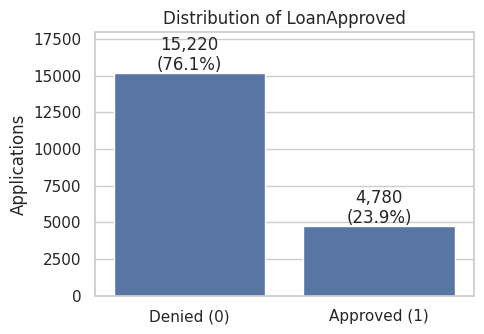

In [7]:
# Target distribution
counts = df["LoanApproved"].value_counts().sort_index()
print(counts, "\n")
print(df["LoanApproved"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=["Denied (0)", "Approved (1)"], y=counts.values, ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 150, f"{v:,}\n({v/len(df):.1%})", ha="center")
ax.set_ylabel("Applications"); ax.set_title("Distribution of LoanApproved"); ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.show()

In [8]:
# Missing values: how many, and do they relate to the outcome?
miss = df.isna().sum()
miss = miss[miss > 0]
miss_table = pd.DataFrame({
    "n_missing": miss,
    "pct_missing": (miss / len(df) * 100).round(2),
    "pct_missing_when_denied": [df.loc[df.LoanApproved == 0, c].isna().mean() * 100 for c in miss.index],
    "pct_missing_when_approved": [df.loc[df.LoanApproved == 1, c].isna().mean() * 100 for c in miss.index],
}).round(2)
miss_table

,n_missing,pct_missing,pct_missing_when_denied,pct_missing_when_approved
EducationLevel,901,4.50,5.92,0.00
MaritalStatus,1331,6.65,6.60,6.82
SavingsAccountBalance,572,2.86,2.77,3.16


**Reading the missing-value pattern.** `MaritalStatus` and `SavingsAccountBalance` are missing at similar rates for approved and denied applicants, so they look random. `EducationLevel` is different: it is never missing for approved applicants. A model given a missing-indicator would exploit that pattern and look better, but it would be learning how the data was recorded, not who is creditworthy. We treat missing education as "unknown" via imputation and flag it as a limitation.

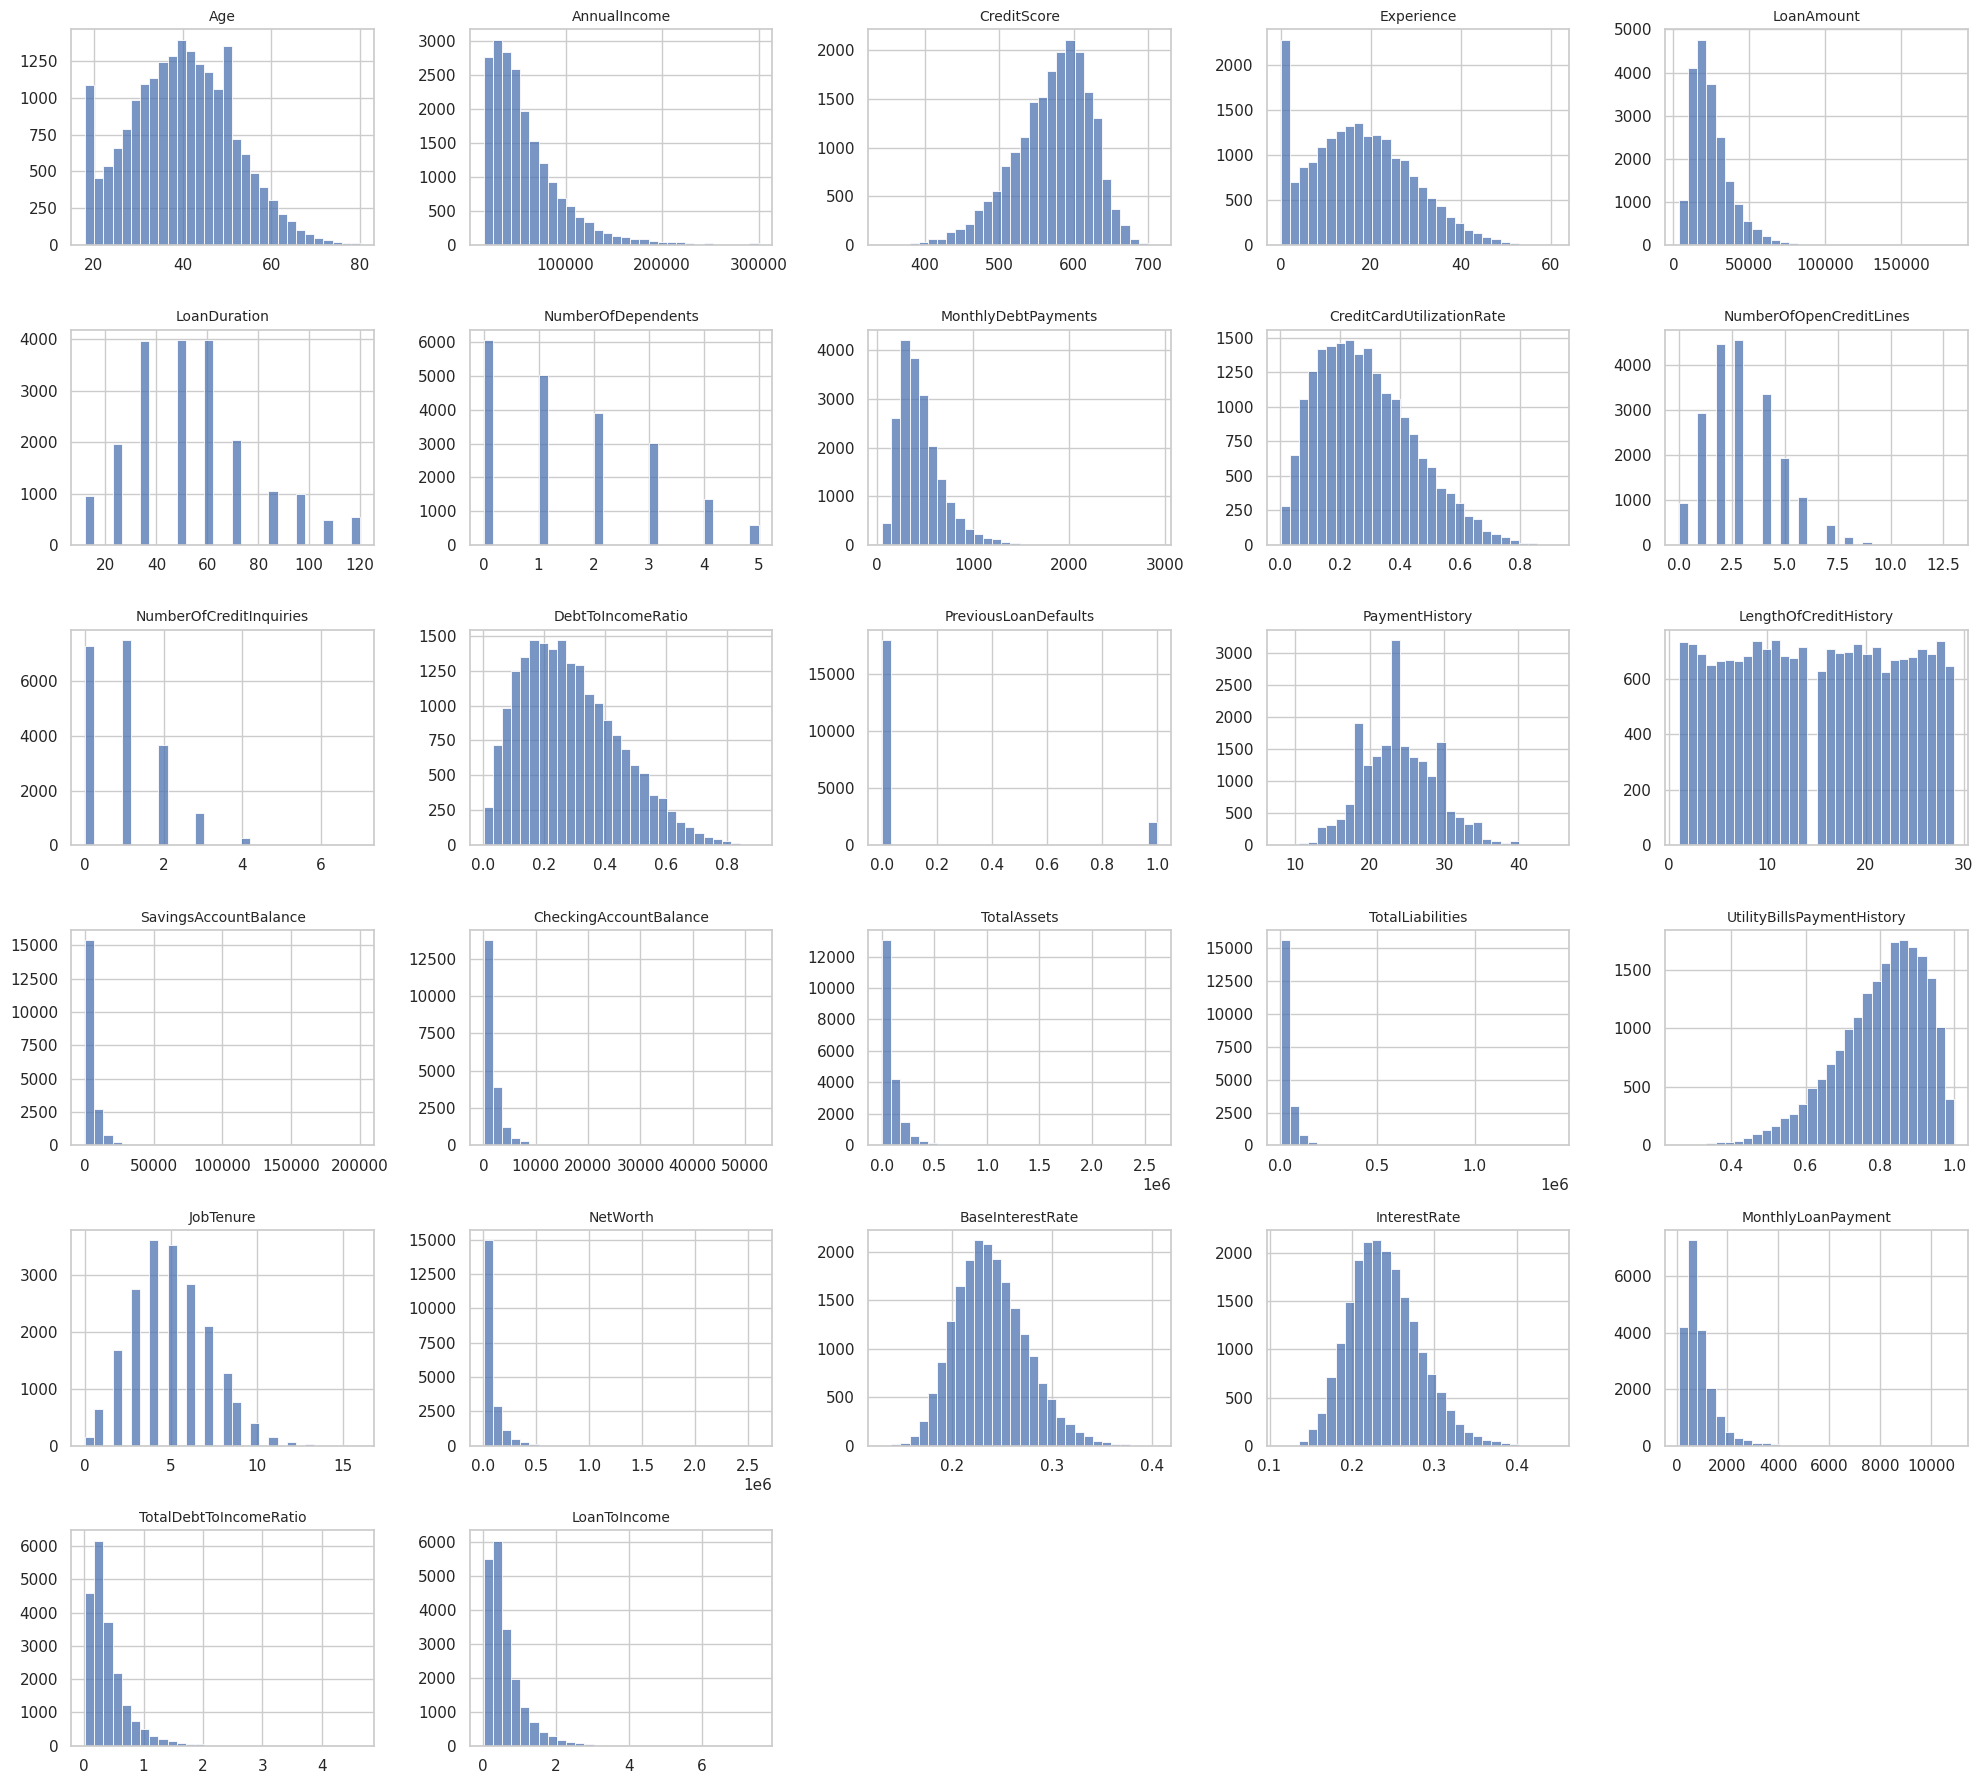

In [9]:
# Distributions of numeric features
num_all = df.select_dtypes("number").drop(columns=["LoanApproved", "RiskScore"]).columns
fig, axes = plt.subplots(6, 5, figsize=(20, 18))
for ax, col in zip(axes.ravel(), num_all):
    sns.histplot(df[col], bins=30, ax=ax)
    ax.set_title(col, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[len(num_all):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

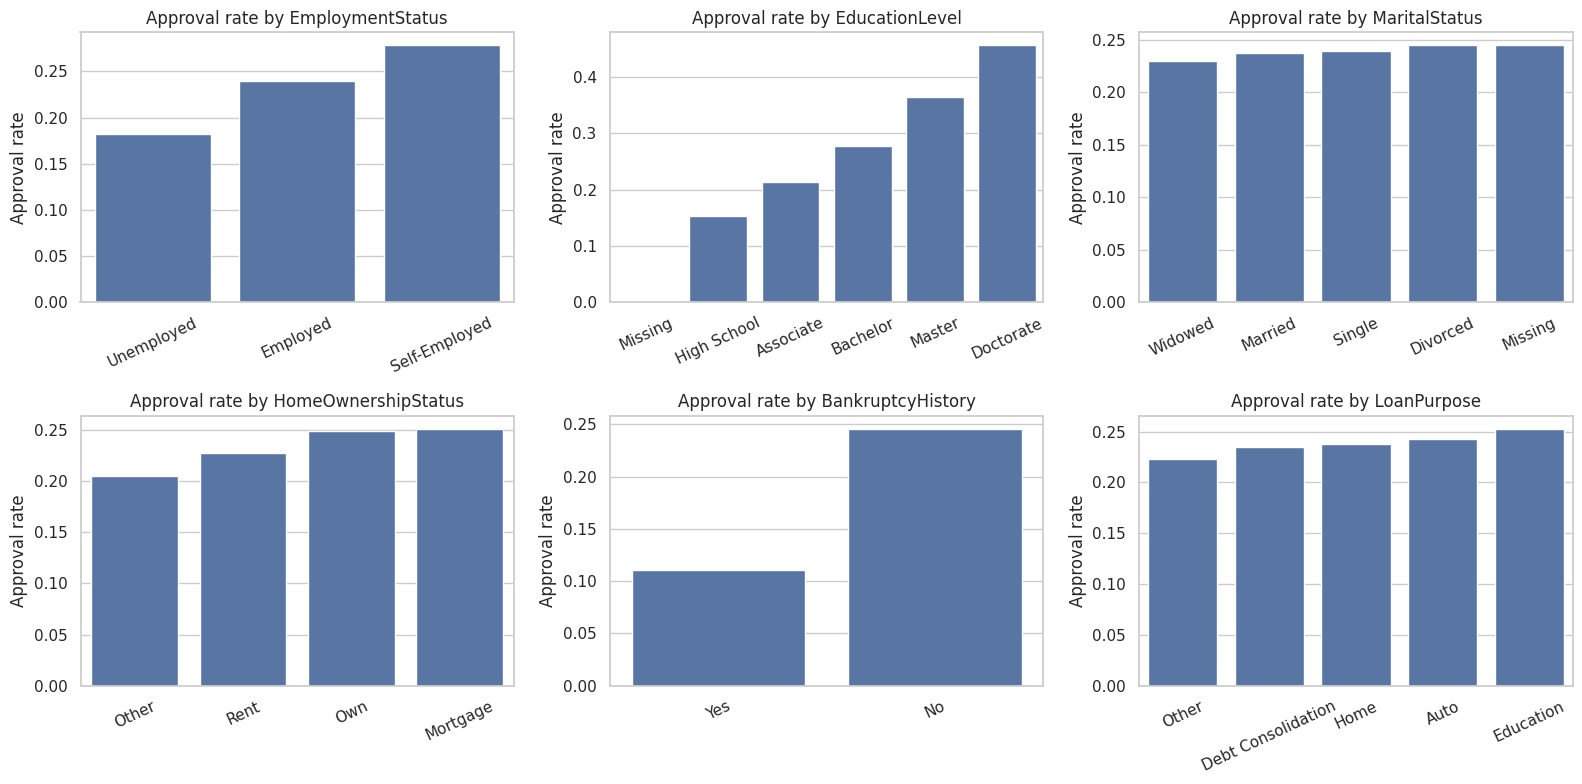

In [10]:
# Categorical features vs approval rate
cat_all = ["EmploymentStatus", "EducationLevel", "MaritalStatus", "HomeOwnershipStatus", "BankruptcyHistory", "LoanPurpose"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), cat_all):
    rate = df.assign(**{col: df[col].fillna("Missing")}).groupby(col)["LoanApproved"].agg(["mean", "size"]).sort_values("mean")
    sns.barplot(x=rate.index, y=rate["mean"], ax=ax)
    ax.set_title(f"Approval rate by {col}"); ax.set_xlabel(""); ax.set_ylabel("Approval rate")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

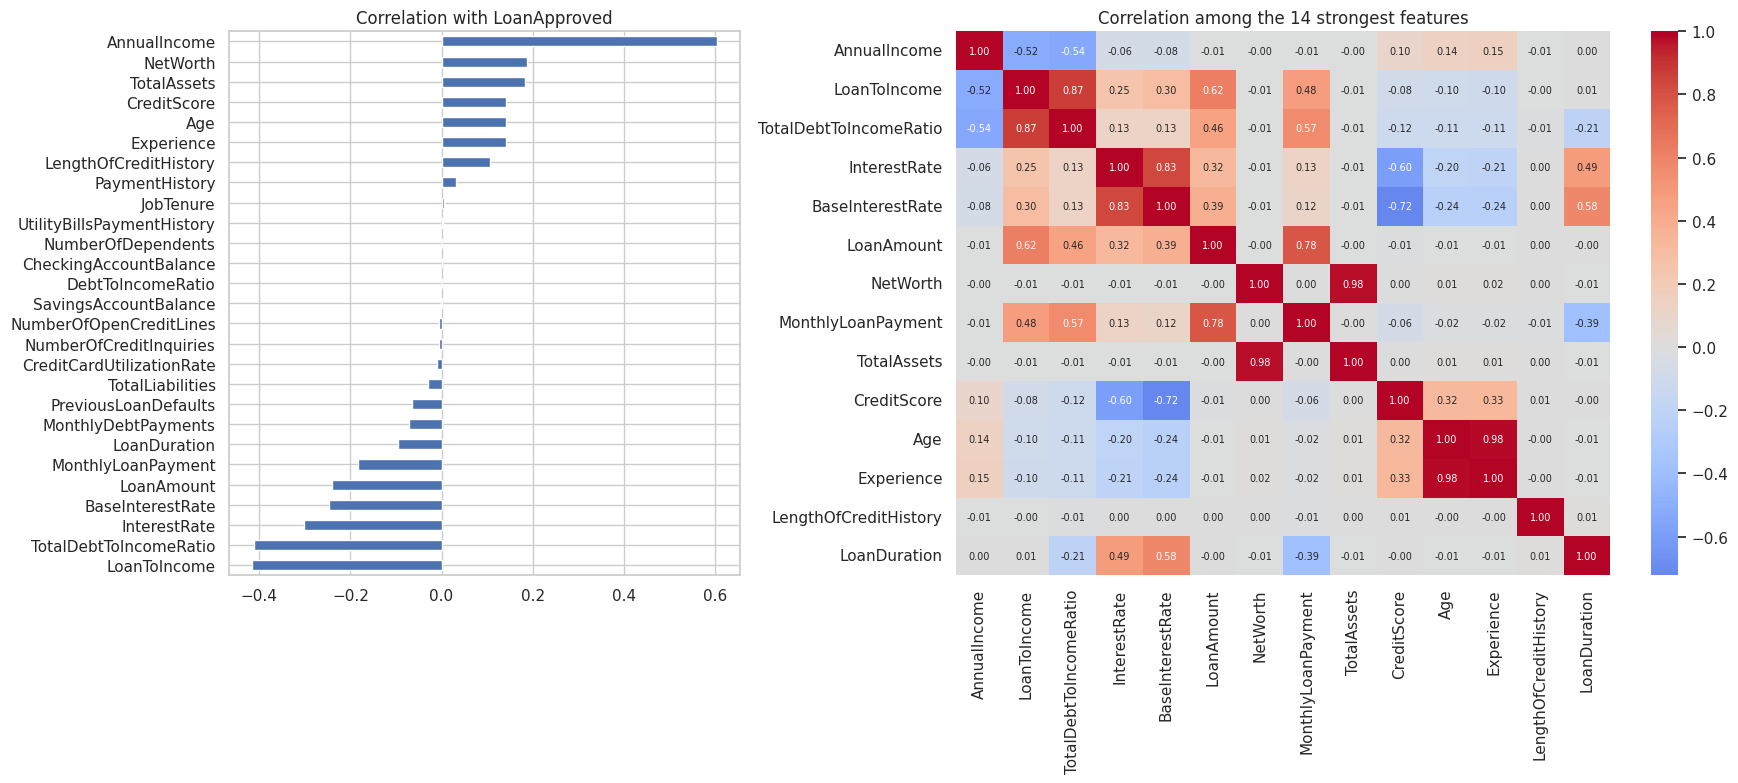

In [11]:
# Relationships: correlation of numeric features with the outcome, and among features
corr_target = df[num_all].corrwith(df["LoanApproved"]).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1, 1.6]})
corr_target.plot(kind="barh", ax=axes[0]); axes[0].set_title("Correlation with LoanApproved")

top = corr_target.abs().sort_values(ascending=False).head(14).index
sns.heatmap(df[list(top)].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("Correlation among the 14 strongest features")
plt.tight_layout(); plt.show()

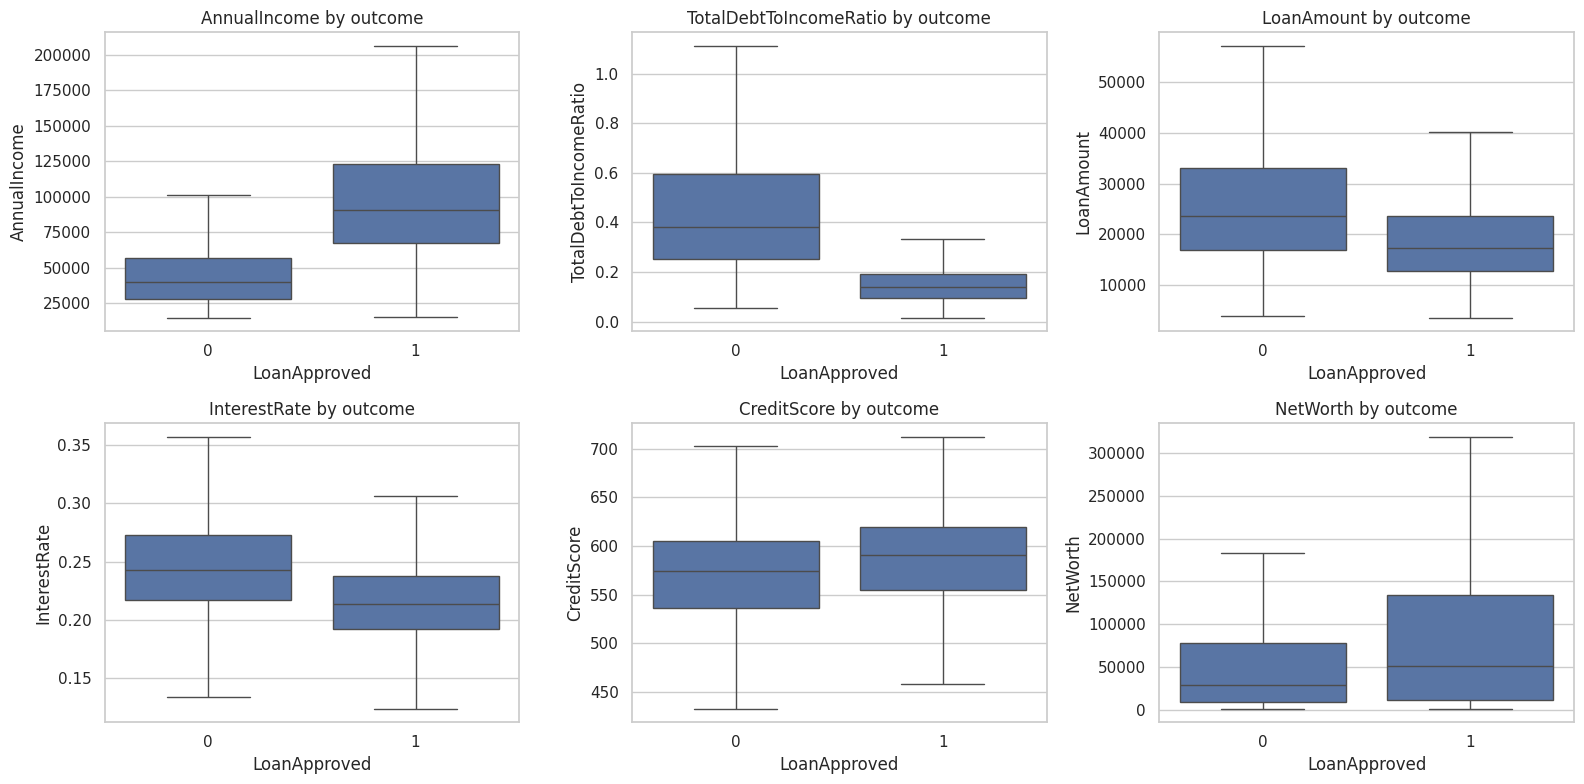

In [12]:
# Key drivers by outcome
key = ["AnnualIncome", "TotalDebtToIncomeRatio", "LoanAmount", "InterestRate", "CreditScore", "NetWorth"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key):
    sns.boxplot(data=df, x="LoanApproved", y=col, ax=ax, showfliers=False)
    ax.set_title(f"{col} by outcome")
plt.tight_layout(); plt.show()

### EDA findings

- **Target:** 23.9% approved vs 76.1% denied. This is moderate imbalance, so we use stratified splits and stratified CV, ROC/PR metrics, and a cost-based threshold rather than resampling.
- **Skew:** `NetWorth`, `TotalAssets`, `SavingsAccountBalance` and `AnnualIncome` are strongly right-skewed. That is fine for trees; for logistic regression standardisation helps, and a log transform would be a future improvement.
- **Strongest relationships with approval:** income (`AnnualIncome` r = +0.60), loan-to-income (engineered, r = -0.42), `TotalDebtToIncomeRatio` (-0.41), `InterestRate` (-0.30), `LoanAmount` (-0.24), and `NetWorth` / `TotalAssets` (+0.19 / +0.18). Approval falls sharply with total DTI: 63% approved when DTI <= 0.2, 14% at 0.2-0.4, and under 2% above 0.4.
- **Categorical patterns:** approval rises with education (High School 15% -> Doctorate 46%), is lower for applicants with a bankruptcy (11% vs 25%) or previous default (16% vs 25%), and lower for the unemployed (18% vs 24%). Loan purpose barely matters (22-25%).
- **Surprises:** `DebtToIncomeRatio` (r ~ 0) is uninformative, unlike `TotalDebtToIncomeRatio`, which matters a lot. Credit score has only a modest direct correlation (+0.14) because it also feeds into the interest rate.
- **Feature engineering opportunities:** loan-to-income (added), log-transforming skewed money columns, payment-to-income, and interaction terms such as income x DTI.

In [13]:
# Leakage check: RiskScore is computed AFTER the decision (the data-generation script scales it by 0.8 for approved loans).
# Show how much it would inflate the model, then exclude it.
tmp = df.dropna(subset=["RiskScore"])
print("ROC-AUC of RiskScore alone as a predictor of approval:", round(roc_auc_score(tmp["LoanApproved"], -tmp["RiskScore"]), 4))
print("Mean RiskScore | denied:", round(df.loc[df.LoanApproved == 0, "RiskScore"].mean(), 1),
      "| approved:", round(df.loc[df.LoanApproved == 1, "RiskScore"].mean(), 1))

ROC-AUC of RiskScore alone as a predictor of approval: 0.9873
Mean RiskScore | denied: 54.1 | approved: 40.1


**Decision:** `RiskScore` is dropped. In a quick check with all other features, adding it pushes cross-validated ROC-AUC to essentially 1.0. That is the classic sign of leakage: the score is computed from the decision, so it would not exist at application time.

`InterestRate` and `MonthlyLoanPayment` are priced from the applicant's credit score, loan amount and duration, so they are treated as available at application time. **This should be confirmed with the business**: if the rate is only set after approval, they should be removed.

### 4. Feature understanding

- **Numeric (27):** age, income, credit score, loan amount and duration, debt and payment amounts, ratios and rates, account balances, assets, liabilities, net worth, interest rates, the engineered `LoanToIncome`, and others.
- **Ordinal (1):** `EducationLevel` (High School < Associate < Bachelor < Master < Doctorate).
- **Categorical (5):** `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory` (Yes/No), `LoanPurpose`.
- **Special preprocessing:** `AnnualIncome` (text and outliers, handled above), `EducationLevel` (ordered encoding, missing values), `MaritalStatus` (missing values), `SavingsAccountBalance` (missing values, heavy skew).
- **Excluded:** the target `LoanApproved`, the leaking `RiskScore`, and the redundant `MonthlyIncome`.

In [14]:
# Feature typing (task 4a) - RiskScore is excluded as leakage; the target is LoanApproved
target = "LoanApproved"
ordinal_cols = ["EducationLevel"]
education_order = ["High School", "Associate", "Bachelor", "Master", "Doctorate"]
categorical_cols = ["EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus", "BankruptcyHistory", "LoanPurpose"]

X = df.drop(columns=[target, "RiskScore"])
y = df[target]
numeric_cols = [c for c in X.columns if c not in ordinal_cols + categorical_cols]
print(f"{len(numeric_cols)} numeric, {len(ordinal_cols)} ordinal, {len(categorical_cols)} categorical features")

27 numeric, 1 ordinal, 5 categorical features


## Data Preparation

### 5. Preprocessing strategy

We split first (80/20, stratified, `random_state=42`) so that no statistic from the test set ever influences preprocessing, tuning or threshold choice. All transformations live inside a `Pipeline` so they are re-fitted within each cross-validation fold.

In [15]:
# Hold out the test set FIRST. All tuning and threshold selection use training data only.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Approval rate  train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

Train: (16000, 33) | Test: (4000, 33)
Approval rate  train: 0.239  test: 0.239


In [16]:
# Preprocessing: separate flows per feature type, combined in a ColumnTransformer
def make_preprocessor(scale=True):
    numeric_flow = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),                      # SavingsAccountBalance has gaps
        ("scaler", StandardScaler() if scale else "passthrough"),
    ])
    ordinal_flow = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),               # EducationLevel has gaps
        ("encoder", OrdinalEncoder(categories=[education_order])),          # natural order kept
        ("scaler", StandardScaler() if scale else "passthrough"),
    ])
    categorical_flow = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),  # MaritalStatus gaps -> own level
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_flow, numeric_cols),
        ("ord", ordinal_flow, ordinal_cols),
        ("cat", categorical_flow, categorical_cols),
    ])

make_preprocessor(scale=True)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

**Reasoning for each choice**

| Feature group | Steps | Why |
|---|---|---|
| Numeric | Median imputation, then `StandardScaler` (only for the linear model) | The median is robust to skew and outliers. Scaling makes regularisation fair for logistic regression and is unnecessary for trees |
| Ordinal (`EducationLevel`) | Most-frequent imputation, `OrdinalEncoder` with explicit order, then scaling | Preserves the natural ranking and needs only one column. Missing education is imputed rather than flagged (see the missingness note) |
| Categorical | Constant `"Unknown"` imputation, then `OneHotEncoder(handle_unknown="ignore")` | No natural order; `"Unknown"` keeps missing marital status as its own level; unseen categories do not crash at prediction time |

`FeatureUnion` was considered but is not needed. `ColumnTransformer` already gives each feature type its own flow, and there are no parallel transformations of the *same* columns to combine. The numeric imputation strategy is exposed as a tunable parameter, so preprocessing is tuned along with the models.

## Modeling

### 6. Modeling approach

- **Algorithms:** (1) **Logistic regression**: interpretable, well suited to regulation, needs scaling. (2) **Random Forest**: nonlinear, robust. (3) **Histogram Gradient Boosting**: usually the strongest tabular model. I used scikit-learn's `HistGradientBoostingClassifier` rather than the classic `GradientBoostingClassifier` because it fits about 25x faster here, which matters for the "be mindful of time" note.
- **Validation:** an 80/20 train/test split, plus 5-fold **stratified** cross-validation on the training set only. The test set is used once, at the end.
- **Pipelines:** every model is a full `Pipeline` (preprocessing + model), so cross-validation and tuning cannot leak information between folds.

In [17]:
# Custom business metric: expected cost per applicant at a chosen approval threshold
def expected_cost(y_true, y_prob, threshold=THEORETICAL_THRESHOLD):
    y_true = np.asarray(y_true)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    false_approvals = ((y_pred == 1) & (y_true == 0)).sum()
    false_denials = ((y_pred == 0) & (y_true == 1)).sum()
    return (false_approvals * COST_FALSE_APPROVAL + false_denials * COST_FALSE_DENIAL) / len(y_true)

# greater_is_better=False -> sklearn reports it as a negative number; we flip the sign when displaying
cost_scorer = make_scorer(expected_cost, response_method="predict_proba", greater_is_better=False)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "cost": cost_scorer}

# Baselines (computed on the training set): no model at all
deny_all = y_train.mean() * COST_FALSE_DENIAL
approve_all = (1 - y_train.mean()) * COST_FALSE_APPROVAL
print(f"Baseline 'deny everyone':    accuracy {1 - y_train.mean():.3f}, cost per applicant ${deny_all:,.0f}")
print(f"Baseline 'approve everyone': accuracy {y_train.mean():.3f}, cost per applicant ${approve_all:,.0f}")

Baseline 'deny everyone':    accuracy 0.761, cost per applicant $1,912
Baseline 'approve everyone': accuracy 0.239, cost per applicant $38,050


`expected_cost` is the custom metric. It is wrapped in a scorer so that cross-validation and the searches can optimise or report it, using probabilities and the 0.862 theoretical threshold.

In [18]:
# Compare three algorithms with 5-fold stratified CV, each in a full Pipeline (preprocessing + model)
models = {
    "Logistic Regression": Pipeline([("prep", make_preprocessor(scale=True)),
                                     ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("prep", make_preprocessor(scale=False)),
                               ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
    "Hist Gradient Boosting": Pipeline([("prep", make_preprocessor(scale=False)),
                                        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
}
rows = []
for name, pipe in models.items():
    r = cross_validate(pipe, X_train, y_train, cv=cv5, scoring={**scoring}, return_train_score=True, n_jobs=1)
    rows.append({"model": name,
                 "cv_roc_auc": r["test_roc_auc"].mean(), "train_roc_auc": r["train_roc_auc"].mean(),
                 "cv_pr_auc": r["test_pr_auc"].mean(),
                 "cv_cost_per_applicant": -r["test_cost"].mean(), "fit_seconds": r["fit_time"].mean()})
baseline_table = pd.DataFrame(rows).set_index("model").round(4)
baseline_table

,cv_roc_auc,train_roc_auc,cv_pr_auc,cv_cost_per_applicant,fit_seconds
model,,,,,
Logistic Regression,0.9946,0.9950,0.9839,539.875,0.1186
Random Forest,0.9770,1.0000,0.9356,1311.500,5.6439
Hist Gradient Boosting,0.9901,0.9995,0.9711,710.125,0.7242


**Reading the comparison.** Logistic regression has the best cross-validated ROC-AUC (0.995), PR-AUC and cost (about $540 per applicant), and its train and CV scores are almost identical (no overfitting). Random Forest memorises the training data (train AUC 1.000 vs CV 0.977) and its uncalibrated probabilities make the cost at a 0.86 threshold poor. Gradient boosting sits in between. This fits how the data was made: the approval label is close to a weighted linear rule plus noise, so a linear model is close to the true structure.

The instructions suggest tuning the model with the most room to improve. To showcase tuning properly, I tune **both** the interpretable leader (small `GridSearchCV`) and the boosting model (broader `RandomizedSearchCV`), then choose on cross-validated evidence.

### 7. Optimising the model

The searches score three metrics at once (`roc_auc`, `pr_auc`, and the custom `cost`) and refit on ROC-AUC. Each search includes a **preprocessing** parameter (`prep__num__imputer__strategy`) alongside model parameters, and `cv_results_` is turned into a table so the impact of every combination is visible.

In [19]:
# GridSearchCV on the interpretable model - includes a PREPROCESSING parameter (numeric imputation strategy)
lr_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "prep__num__imputer__strategy": ["median", "mean"],
}
lr_search = GridSearchCV(models["Logistic Regression"], lr_grid, cv=cv5, scoring=scoring, refit="roc_auc", n_jobs=1)
lr_search.fit(X_train, y_train)

def tidy(search, param_cols):
    res = pd.DataFrame(search.cv_results_)
    out = res[param_cols + ["mean_test_roc_auc", "mean_test_pr_auc", "mean_test_cost", "mean_fit_time"]].copy()
    out["mean_test_cost"] = -out["mean_test_cost"]
    out.columns = [c.replace("param_", "") for c in out.columns]
    return out.sort_values("mean_test_roc_auc", ascending=False).round(4)

tidy(lr_search, ["param_model__C", "param_prep__num__imputer__strategy"])

,model__C,prep__num__imputer__strategy,mean_test_roc_auc,mean_test_pr_auc,mean_test_cost,mean_fit_time
6,10.00,median,0.9947,0.9841,533.250,0.0949
7,10.00,mean,0.9947,0.9841,532.750,0.0849
4,1.00,median,0.9946,0.9839,539.875,0.1167
5,1.00,mean,0.9946,0.9839,538.375,0.1060
2,0.10,median,0.9941,0.9825,613.750,0.0839
3,0.10,mean,0.9941,0.9825,614.250,0.0751
1,0.01,mean,0.9915,0.9747,1035.000,0.0598
0,0.01,median,0.9915,0.9747,1036.000,0.0714


In [20]:
# RandomizedSearchCV on the boosting model - broad search, limited budget (showcasing "how to tune")
gb_dist = {
    "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "model__max_iter": [100, 200, 300],
    "model__max_leaf_nodes": [8, 15, 31],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 1.0, 10.0],
    "prep__num__imputer__strategy": ["median", "mean"],
}
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
gb_search = RandomizedSearchCV(models["Hist Gradient Boosting"], gb_dist, n_iter=15, cv=cv3,
                               scoring=scoring, refit="roc_auc", random_state=RANDOM_STATE, n_jobs=1)
gb_search.fit(X_train, y_train)

gb_params = [f"param_{k}" for k in gb_dist]
print("Best GB params:", gb_search.best_params_)
tidy(gb_search, gb_params).head(8)

Best GB params: {'prep__num__imputer__strategy': 'mean', 'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 8, 'model__max_iter': 300, 'model__learning_rate': 0.2, 'model__l2_regularization': 10.0}


,model__learning_rate,model__max_iter,model__max_leaf_nodes,model__min_samples_leaf,model__l2_regularization,prep__num__imputer__strategy,mean_test_roc_auc,mean_test_pr_auc,mean_test_cost,mean_fit_time
0,0.20,300,8,100,10.0,mean,0.9917,0.9757,629.7528,0.6580
6,0.20,200,8,20,0.0,mean,0.9915,0.9752,656.6275,0.5185
7,0.10,200,8,100,0.0,mean,0.9914,0.9752,676.6280,0.6491
10,0.20,100,15,100,10.0,mean,0.9908,0.9731,677.0021,0.4488
2,0.10,300,31,100,10.0,mean,0.9902,0.9716,710.4999,1.0806
13,0.05,200,15,50,0.0,mean,0.9901,0.9715,744.5015,0.8372
3,0.20,300,31,50,1.0,mean,0.9896,0.9696,718.3762,0.4995
4,0.05,200,8,20,0.0,median,0.9888,0.9678,864.2511,0.6845


In [21]:
# Impact of individual hyperparameters (mean CV ROC-AUC by value)
gb_res = pd.DataFrame(gb_search.cv_results_)
for p in ["param_model__learning_rate", "param_model__max_leaf_nodes", "param_model__l2_regularization"]:
    print(gb_res.groupby(p)["mean_test_roc_auc"].mean().round(4).to_string(), "\n")

param_model__learning_rate
0.03    0.9820
0.05    0.9873
0.10    0.9908
0.20    0.9909 

param_model__max_leaf_nodes
8     0.9875
15    0.9878
31    0.9859 

param_model__l2_regularization
0.0     0.9905
1.0     0.9840
10.0    0.9877 



In [22]:
# Select the final model on CV evidence (5-fold for LR; 3-fold for the randomized GB search)
summary = pd.DataFrame({
    "Tuned Logistic Regression": [lr_search.best_score_, -lr_search.cv_results_["mean_test_cost"][lr_search.best_index_],
                                  lr_search.cv_results_["mean_test_pr_auc"][lr_search.best_index_]],
    "Tuned Hist Gradient Boosting": [gb_search.best_score_, -gb_search.cv_results_["mean_test_cost"][gb_search.best_index_],
                                     gb_search.cv_results_["mean_test_pr_auc"][gb_search.best_index_]],
}, index=["cv_roc_auc", "cv_cost_per_applicant", "cv_pr_auc"]).round(4)
summary

,Tuned Logistic Regression,Tuned Hist Gradient Boosting
cv_roc_auc,0.9947,0.9917
cv_cost_per_applicant,533.2500,629.7528
cv_pr_auc,0.9841,0.9757


**What the tuning showed**

- **Logistic regression:** regularisation matters at the low end (C = 0.01 is clearly worse: cost about $1,035 vs about $533 at C = 10), but gains flatten from C = 1 upward. C = 10 is at the edge of the grid, so a wider grid could be tried, though the improvement would be marginal. Median vs mean imputation makes essentially no difference.
- **Gradient boosting:** a higher learning rate helped (mean CV AUC 0.982 at 0.03 vs 0.991 at 0.2), and small trees with strong regularisation (8 leaves, `min_samples_leaf`=100, L2 = 10) were best. Even so, its best CV ROC-AUC (0.992) and cost (about $630 per applicant) stay behind the tuned logistic regression.
- **Trade-off and choice:** the tuned logistic regression is at least as accurate, much faster to fit, and far easier to explain. **It is the final model.** (Caveat: the GB search used 3-fold CV to save time and the LR search used 5-fold, so the comparison is indicative rather than exact.)

Cost-minimising threshold on training OOF predictions: 0.85 (theoretical: 0.862), cost/applicant $524


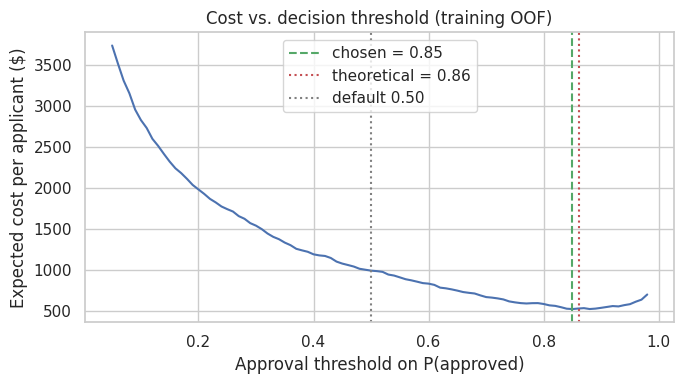

In [23]:
# Choose the decision threshold from OUT-OF-FOLD training predictions (never from the test set)
final_model = lr_search.best_estimator_
oof_prob = cross_val_predict(final_model, X_train, y_train, cv=cv5, method="predict_proba")[:, 1]

grid = np.round(np.arange(0.05, 0.99, 0.01), 2)
cost_curve = np.array([expected_cost(y_train, oof_prob, t) for t in grid])
best_threshold = grid[cost_curve.argmin()]
print(f"Cost-minimising threshold on training OOF predictions: {best_threshold:.2f} "
      f"(theoretical: {THEORETICAL_THRESHOLD:.3f}), cost/applicant ${cost_curve.min():,.0f}")

plt.figure(figsize=(7, 4))
plt.plot(grid, cost_curve)
plt.axvline(best_threshold, color="g", ls="--", label=f"chosen = {best_threshold:.2f}")
plt.axvline(THEORETICAL_THRESHOLD, color="r", ls=":", label=f"theoretical = {THEORETICAL_THRESHOLD:.2f}")
plt.axvline(0.5, color="gray", ls=":", label="default 0.50")
plt.xlabel("Approval threshold on P(approved)"); plt.ylabel("Expected cost per applicant ($)")
plt.title("Cost vs. decision threshold (training OOF)"); plt.legend(); plt.tight_layout(); plt.show()

**Threshold.** The cost-minimising threshold from out-of-fold training predictions (0.85) is very close to the theoretical 0.862, which suggests the model's probabilities are reasonably well calibrated. The default 0.50 is clearly worse. We use **0.85**, chosen *without* looking at the test set.

## Evaluation and Conclusion

### 8. Final model evaluation (test set)

In [24]:
# Final evaluation on the untouched test set
final_model.fit(X_train, y_train)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

test_metrics = {
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "PR-AUC": average_precision_score(y_test, test_prob),
    "Accuracy @ chosen threshold": accuracy_score(y_test, test_pred),
    "Cost/applicant @ chosen threshold": expected_cost(y_test, test_prob, best_threshold),
    "Cost/applicant @ default 0.50": expected_cost(y_test, test_prob, 0.5),
}
deny_all_test = y_test.mean() * COST_FALSE_DENIAL
approve_all_test = (1 - y_test.mean()) * COST_FALSE_APPROVAL
for k, v in test_metrics.items():
    print(f"{k:38s} {v:,.4f}" if "Cost" not in k else f"{k:38s} ${v:,.0f}")
print(f"{'Baseline deny-all cost/applicant':38s} ${deny_all_test:,.0f}")
print(f"{'Baseline approve-all cost/applicant':38s} ${approve_all_test:,.0f}")
print()
print(classification_report(y_test, test_pred, target_names=["Denied", "Approved"]))

ROC-AUC                                0.9946
PR-AUC                                 0.9836
Accuracy @ chosen threshold            0.9497
Cost/applicant @ chosen threshold      $602
Cost/applicant @ default 0.50          $978
Baseline deny-all cost/applicant       $1,912
Baseline approve-all cost/applicant    $38,050

              precision    recall  f1-score   support

      Denied       0.94      0.99      0.97      3044
    Approved       0.98      0.81      0.89       956

    accuracy                           0.95      4000
   macro avg       0.96      0.90      0.93      4000
weighted avg       0.95      0.95      0.95      4000



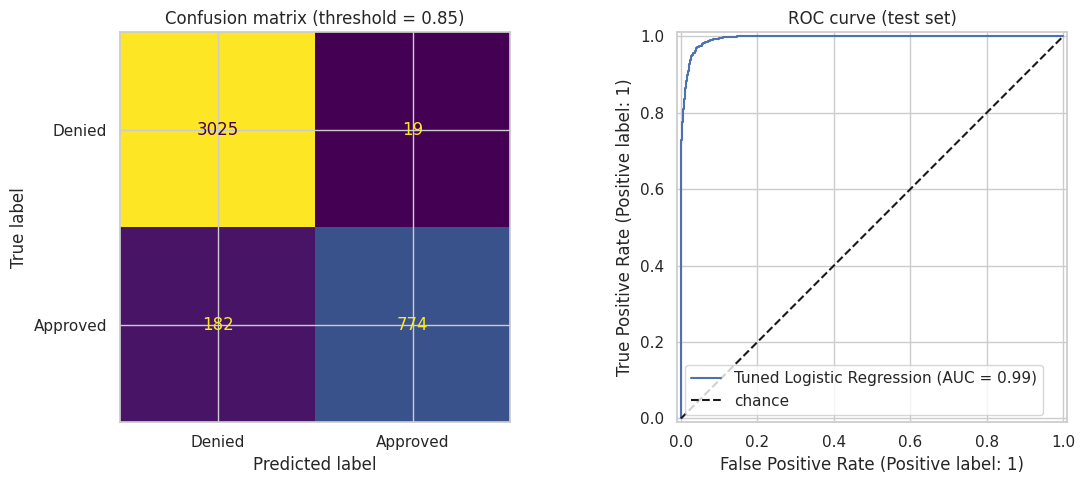

False approvals: 19  ($950,000)   False denials: 182  ($1,456,000)


In [25]:
# Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=["Denied", "Approved"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix (threshold = {best_threshold:.2f})")
RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[1], name="Tuned Logistic Regression")
axes[1].plot([0, 1], [0, 1], "k--", label="chance"); axes[1].set_title("ROC curve (test set)"); axes[1].legend()
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
print(f"False approvals: {fp}  (${fp * COST_FALSE_APPROVAL:,})   False denials: {fn}  (${fn * COST_FALSE_DENIAL:,})")

In [26]:
# Business impact on the 4,000-application test set
n = len(y_test)
impact = pd.DataFrame({
    "cost_per_applicant": [expected_cost(y_test, test_prob, best_threshold), deny_all_test, approve_all_test],
}, index=["Model (tuned threshold)", "Deny everyone", "Approve everyone"])
impact["total_cost_on_test_set"] = impact["cost_per_applicant"] * n
impact["savings_vs_deny_all"] = impact.loc["Deny everyone", "total_cost_on_test_set"] - impact["total_cost_on_test_set"]
impact.style.format("${:,.0f}")

,cost_per_applicant,total_cost_on_test_set,savings_vs_deny_all
Model (tuned threshold),$602,"$2,406,000","$5,242,000"
Deny everyone,"$1,912","$7,648,000",$0
Approve everyone,"$38,050","$152,200,000","$-144,552,000"


**Results against the success criteria**

- **ROC-AUC 0.995 and PR-AUC 0.984** on the test set match cross-validation, so there is no sign of overfitting or leakage from the test set.
- **Precision on approvals is 0.98** (target >= 0.95). Only **19 false approvals** out of 4,000 applications (about $950k), because the threshold makes the model cautious.
- **Recall on approvals is 0.81.** The model gives up about 19% of truly approvable applicants (182 false denials, about $1.46M) in exchange for very few bad approvals. That is the intended trade-off given the 6.25x cost ratio.
- **Cost per applicant is about $602**, versus $1,912 for deny-all and $38,050 for approve-all. Using the default 0.50 threshold would cost about $978, so the cost-based threshold alone saves roughly $1.5M on this test set.

A caution: scores this high are unusual in real credit data. The approval label was generated by a formula plus noise, so a linear model can recover it almost perfectly. Real-world performance would be lower.

In [27]:
# Performance across segments (test set) - also a first look at fairness
def segment_report(series, name):
    seg = series.astype(object).where(series.notna(), "Missing").astype(str)
    rows = []
    for g in sorted(seg.unique()):
        m = (seg == g).values
        yt, pr = y_test.values[m], test_prob[m]
        rows.append({name: g, "n": m.sum(), "actual_approval_rate": yt.mean(),
                     "predicted_approval_rate": (pr >= best_threshold).mean(),
                     "roc_auc": roc_auc_score(yt, pr) if len(np.unique(yt)) > 1 else np.nan,
                     "cost_per_applicant": expected_cost(yt, pr, best_threshold)})
    return pd.DataFrame(rows).set_index(name).round(3)

age_band = pd.cut(X_test["Age"], [17, 30, 45, 60, 100], labels=["18-30", "31-45", "46-60", "61+"])
for series, name in [(X_test["EducationLevel"], "EducationLevel"), (X_test["EmploymentStatus"], "EmploymentStatus"),
                     (X_test["HomeOwnershipStatus"], "HomeOwnershipStatus"), (X_test["MaritalStatus"], "MaritalStatus"),
                     (age_band, "AgeBand")]:
    display(segment_report(series, name))

,n,actual_approval_rate,predicted_approval_rate,roc_auc,cost_per_applicant
EducationLevel,,,,,
Associate,782,0.207,0.160,0.993,749.361
Bachelor,1163,0.279,0.237,0.995,636.285
Doctorate,156,0.442,0.397,0.990,358.974
High School,1086,0.153,0.121,0.997,418.048
Master,620,0.377,0.319,0.993,838.710
Missing,193,0.000,0.005,NaN,259.067


,n,actual_approval_rate,predicted_approval_rate,roc_auc,cost_per_applicant
EmploymentStatus,,,,,
Employed,3402,0.242,0.200,0.995,562.610
Self-Employed,311,0.264,0.241,0.993,926.045
Unemployed,287,0.174,0.136,0.993,710.801


,n,actual_approval_rate,predicted_approval_rate,roc_auc,cost_per_applicant
HomeOwnershipStatus,,,,,
Mortgage,1624,0.249,0.203,0.993,731.527
Other,415,0.173,0.152,0.994,592.771
Own,786,0.265,0.218,0.994,524.173
Rent,1175,0.231,0.196,0.997,476.596


,n,actual_approval_rate,predicted_approval_rate,roc_auc,cost_per_applicant
MaritalStatus,,,,,
Divorced,506,0.227,0.178,0.994,624.506
Married,1911,0.234,0.199,0.996,519.100
Missing,267,0.292,0.255,0.997,516.854
Single,1152,0.240,0.192,0.993,684.028
Widowed,164,0.244,0.201,0.991,1048.780


,n,actual_approval_rate,predicted_approval_rate,roc_auc,cost_per_applicant
AgeBand,,,,,
18-30,870,0.134,0.124,0.994,482.759
31-45,1890,0.244,0.186,0.994,623.280
46-60,1085,0.296,0.252,0.998,460.829
61+,155,0.361,0.394,0.996,1987.097


### Segment performance, bias and limitations

- **Consistent ranking quality:** ROC-AUC is 0.99 or higher in every segment, so the model ranks applicants well for all groups.
- **Systematically conservative:** predicted approval rates sit below actual rates in nearly every segment. That is expected with a 0.85 threshold, but it means the model *denies more* applicants than the historical process did.
- **Watch the small groups:** applicants aged 61+ (n = 155) have the highest cost per applicant (about $2,000) and are the only age band where predicted approvals exceed actual ones. Widowed applicants (n = 164) also show a higher cost. These samples are small and the differences may be noise, but they should be monitored.
- **Missing education (n = 193):** all were historically denied and the model predicts almost none as approved, but this reflects the data-recording artefact discussed earlier.
- **Fairness and regulation.** `Age` and `MaritalStatus` are inputs, and fair-lending rules in many jurisdictions (for example ECOA in the US) restrict how these may be used in credit decisions. This is not legal advice; compliance should review it. A production version should be re-trained without them and re-tested. Other features (home ownership, employment, education) can act as proxies for protected characteristics and should be audited.
- **Other limitations:** the label is a past decision, not repayment (so past bias is learned); the data is synthetic and rule-based; we have no information on applicants the historical process never saw (selection bias); and the dollar costs are averages, not per-loan values.

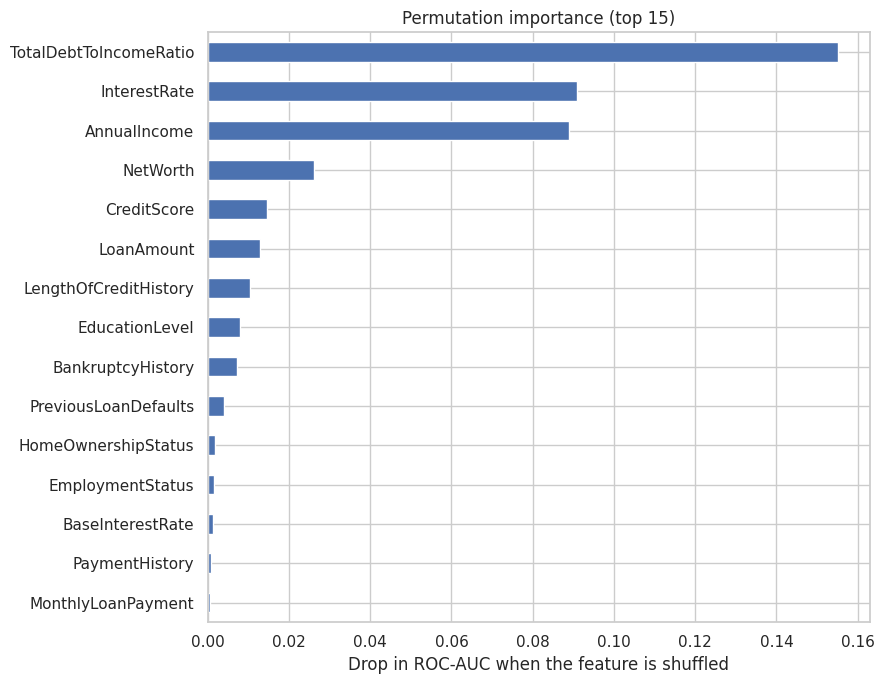

TotalDebtToIncomeRatio    0.1552
InterestRate              0.0910
AnnualIncome              0.0888
NetWorth                  0.0261
CreditScore               0.0147
LoanAmount                0.0129
LengthOfCreditHistory     0.0105
EducationLevel            0.0080
BankruptcyHistory         0.0073
PreviousLoanDefaults      0.0041
dtype: float64

In [28]:
# Feature importance: permutation importance on the test set, on the ORIGINAL columns
perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
imp.head(15).iloc[::-1].plot(kind="barh")
plt.xlabel("Drop in ROC-AUC when the feature is shuffled"); plt.title("Permutation importance (top 15)")
plt.tight_layout(); plt.show()
imp.head(10).round(4)

In [29]:
# Direction of effect from the logistic regression coefficients (standardised features)
names = final_model.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(final_model.named_steps["model"].coef_[0], index=names).sort_values()
pd.concat([coefs.head(6), coefs.tail(6)]).round(2)

num__TotalDebtToIncomeRatio        -10.35
cat__BankruptcyHistory_Yes          -6.49
num__InterestRate                   -5.84
cat__EmploymentStatus_Unemployed    -4.28
num__LoanAmount                     -2.44
num__CreditScore                    -2.33
num__BaseInterestRate                0.56
cat__BankruptcyHistory_No            0.71
ord__EducationLevel                  1.63
num__LengthOfCreditHistory           1.88
num__NetWorth                        3.06
num__AnnualIncome                    5.12
dtype: float64

### 9. Feature importance and interpretation

**Which features matter most (permutation importance on the test set):**
1. **`TotalDebtToIncomeRatio`** is by far the most important (a ROC-AUC drop of about 0.155 when shuffled), followed by
2. **`InterestRate`** (0.091) and
3. **`AnnualIncome`** (0.089), then `NetWorth`, `CreditScore`, `LoanAmount` and `LengthOfCreditHistory`.

**Direction of effect (logistic regression coefficients on standardised features):** higher total DTI (-10.4), a bankruptcy on record (-6.5), a higher interest rate (-5.8) and unemployment (-4.3) lower the chance of approval, while higher income (+5.1), net worth (+3.1) and longer credit history (+1.9) raise it. These signs match credit-risk intuition. (Because some features overlap, such as `InterestRate` and `BaseInterestRate`, individual coefficient sizes should be read as directional.)

**Business recommendations from the drivers**
- **Affordability drives decisions.** Applicants with total DTI above about 0.4 are almost never approved. Offering smaller loan amounts or longer terms to borderline-DTI applicants is a way to turn some denials into profitable approvals.
- **Pricing and approval are linked.** Higher rates are associated with denial, so review whether risk-based pricing is pushing marginal applicants over the line.
- **Bankruptcy and unemployment** are strong negatives; a manual-review lane for such applicants (for example, recent recovery or new employment) could recover some of the false denials.

### 10. Executive summary (for business stakeholders)

**What we built.** A model that predicts, for each loan application, the probability it would be approved under our historical standards, plus a decision rule that approves only when that probability is high enough (about 85%) to justify the risk.

**Why it matters.** Wrongly approving a loan costs about six times more than wrongly declining one, so the model is deliberately cautious. On 4,000 held-out applications it would have made 19 wrong approvals and 182 wrong denials, for a total cost of about **$2.4M**. Denying everyone would have cost **$7.6M** and approving everyone about **$152M**. That is a saving of about **$5.2M (68%)** compared with the best simple alternative.

**Why you can trust it.** It is a transparent scoring formula, not a black box: it gives the same answer for the same applicant, every decision can be explained by the factors below, and its accuracy held up on data it had never seen.

**What drives decisions.** Total debt-to-income ratio (by far the largest factor), the interest rate offered, income, net worth and credit history. Bankruptcy and unemployment count strongly against an applicant.

**Caveats.** The model copies past decisions (including any bias in them), was built on synthetic data, and uses age and marital status, which need a compliance review before use.

### Recommendations for implementation

1. **Run as decision support first.** Show loan officers the model's probability and top factors, and let them override. Track override rates and outcomes for 3-6 months before any automation.
2. **Automate only the clear cases.** Auto-approve at very high probabilities and auto-deny at very low ones. Send the middle band to manual review, which is where officers add the most value.
3. **Compliance review before launch.** Decide whether `Age` and `MaritalStatus` may be used, re-train without them if not, and audit proxy features. Document the model for regulators.
4. **Re-set the threshold as costs change.** The threshold comes directly from the $50,000 / $8,000 costs. If those change, it is a one-line recalculation.
5. **Monitor in production.** Track drift in the input distributions, approval rate, and per-segment error rates, and re-train on a schedule.

### Potential improvements

- **Use real outcomes.** Train on repayment / default data instead of past decisions, so the model predicts creditworthiness rather than replicating the old process. This is the single most important upgrade.
- **Handle selection bias** with reject-inference techniques, since we never observe outcomes for denied applicants.
- **Fairness work:** formal disparate-impact testing, removal of protected attributes and their proxies, and threshold analysis per group.
- **Richer modelling:** log transforms and interaction terms for the linear model, calibration of probabilities (Platt or isotonic), a wider `C` grid, and a longer boosting search or the classic `GradientBoostingClassifier` on faster hardware.
- **Cost model:** replace the flat $8,000 / $50,000 with per-loan costs that depend on loan amount and term.
- **Explainability:** add SHAP values or per-applicant reason codes for adverse-action notices.